<a href="https://colab.research.google.com/github/mail2venkie/fastbook/blob/temp/myclean/06_image_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#hide
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.0 MB/s eta 0:00:00
Mounted at /content/gdrive


In [2]:
#hide
from fastbook import *

In [3]:
from fastai.vision.all import *
path = untar_data(URLs.BIWI_HEAD_POSE)
path.ls()

(#50) [Path('/root/.fastai/data/biwi_head_pose/04.obj'),Path('/root/.fastai/data/biwi_head_pose/22.obj'),Path('/root/.fastai/data/biwi_head_pose/12'),Path('/root/.fastai/data/biwi_head_pose/23.obj'),Path('/root/.fastai/data/biwi_head_pose/07'),Path('/root/.fastai/data/biwi_head_pose/24'),Path('/root/.fastai/data/biwi_head_pose/02.obj'),Path('/root/.fastai/data/biwi_head_pose/20'),Path('/root/.fastai/data/biwi_head_pose/12.obj'),Path('/root/.fastai/data/biwi_head_pose/21'),Path('/root/.fastai/data/biwi_head_pose/19'),Path('/root/.fastai/data/biwi_head_pose/10.obj'),Path('/root/.fastai/data/biwi_head_pose/03'),Path('/root/.fastai/data/biwi_head_pose/21.obj'),Path('/root/.fastai/data/biwi_head_pose/14'),Path('/root/.fastai/data/biwi_head_pose/11'),Path('/root/.fastai/data/biwi_head_pose/readme.txt'),Path('/root/.fastai/data/biwi_head_pose/11.obj'),Path('/root/.fastai/data/biwi_head_pose/08.obj'),Path('/root/.fastai/data/biwi_head_pose/24.obj')...]

In [5]:
(path/'01').ls().sorted()

(#1000) [Path('/root/.fastai/data/biwi_head_pose/01/depth.cal'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00003_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00003_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00004_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00004_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00005_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00005_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00006_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00006_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00007_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00007_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00008_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00008_rgb.jpg'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00009_pose.txt'),Path('/root/.fastai/data/biwi_head_pose/01/frame_00009_rgb.jpg'),Path('/root/.fastai

In [4]:
image_files = get_image_files(path)
image_files[0]

Path('/root/.fastai/data/biwi_head_pose/12/frame_00608_rgb.jpg')

First problem is to define the dependent variable. In this case, its the coordinates to the center of the face. Target coordinates are availabe in the dataset in the '_pose.txt' file alongside each image file.

Writing a custom function to get the 'pose' file of the same name

In [5]:
def img2pose(fileName):
  return f'{str(fileName)[:-7]}pose.txt'

Seems to work!

In [6]:
f = image_files[0]
img2pose(f)

'/root/.fastai/data/biwi_head_pose/12/frame_00608_pose.txt'

Inspecting the 'pose' file. Apparently only the last line is relevant, per the book chapter.

In [30]:
poseFile = Path(img2pose(f))
pose = np.genfromtxt(poseFile, skip_header=3)
pose

array([ 31.3376,  35.2462, 864.989 ])

function defined. This will be 'get_y' in the datablock

In [6]:
cal = np.genfromtxt(path/'01'/'rgb.cal', skip_footer=6)
def get_center(imgFile):
  ctr = np.genfromtxt(Path(img2pose(imgFile)), skip_header=3)
  c1 = ctr[0] * cal[0][0] / ctr[2] + cal[0][2]
  c2 = ctr[1] * cal[1][1] / ctr[2] + cal[1][2]
  return tensor([c1,c2])

Test the function

In [8]:
get_center(image_files[0])

tensor([338.7549, 261.5941])

Define the datablock

In [7]:
biwi = DataBlock (
    blocks= (ImageBlock, PointBlock),
    get_items = get_image_files,
    get_y = get_center,
    splitter = FuncSplitter(lambda o: o.parent.name=='13'),
    batch_tfms=aug_transforms(size=(240,320))
)

In [8]:
dls = biwi.dataloaders(path)

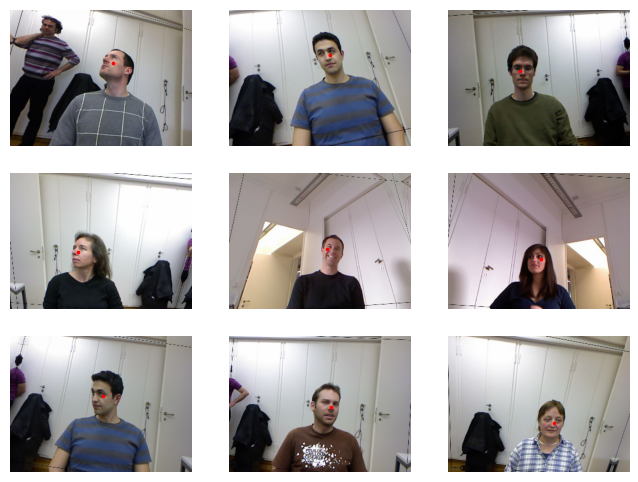

In [9]:
dls.show_batch (max_n=9, figsize=(8,6))

In [10]:
x,y = dls.one_batch()

In [11]:
x.shape

torch.Size([64, 3, 240, 320])

In [12]:
y.shape

torch.Size([64, 1, 2])

In [15]:
y[0]

TensorPoint([[-0.2555, -0.0908]])

In [13]:
learn_onebatch = vision_learner(dls, resnet18)
acts_onebatch = learn_onebatch.model(x)
acts_onebatch

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 92.5MB/s]


TensorImage([[-3.1708,  1.8183],
             [-2.4221,  1.2534],
             [ 0.8328, -1.2375],
             [-0.1031,  4.6004],
             [ 0.7035,  0.4906],
             [-3.1312, -1.1505],
             [-1.0520,  0.4699],
             [ 1.9534, -0.3511],
             [-0.3443, -1.3371],
             [ 1.7849,  2.4244],
             [-2.1469, -1.2457],
             [ 0.1391,  0.3220],
             [-3.1103, -0.9256],
             [-0.0605,  1.0156],
             [ 1.1252,  1.9116],
             [-5.7785,  1.9059],
             [ 1.2819,  3.5870],
             [ 1.8459, -5.0375],
             [-2.0475,  0.9325],
             [ 1.4805,  1.0999],
             [ 0.9030,  0.1743],
             [ 3.7605,  1.1138],
             [ 0.6798, -0.3463],
             [ 3.0922, -0.7280],
             [-0.8782, -3.1305],
             [-0.7662, -0.2271],
             [ 0.9386, -1.4421],
             [ 1.1036,  1.2087],
             [ 3.8148,  0.9197],
             [-1.0416, -1.6218],
          

In [14]:
acts_onebatch.shape

torch.Size([64, 2])

In [17]:
dls.loss_func

FlattenedLoss of MSELoss()

In [10]:
learn = vision_learner(dls, resnet18, y_range=(-1,1))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


SuggestedLRs(valley=0.0005754399462603033)

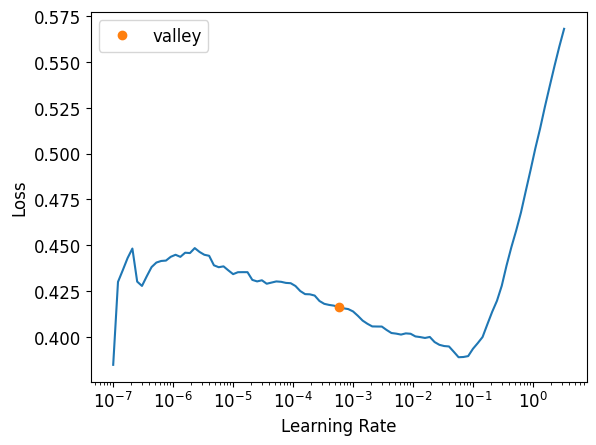

In [11]:
learn.lr_find()

In [12]:
lr = 1e-2

In [14]:
learn.fine_tune(epochs=3, base_lr=lr)

epoch,train_loss,valid_loss,time
0,0.048311,0.010401,01:23


epoch,train_loss,valid_loss,time
0,0.008279,0.002018,01:36
1,0.003045,0.000118,01:35
2,0.001464,0.000199,01:35


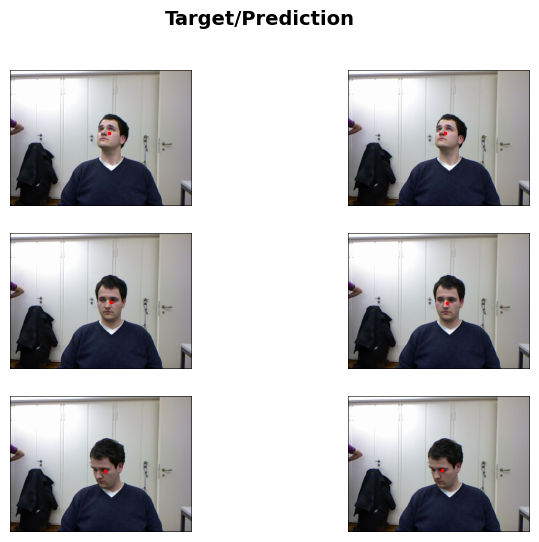

In [15]:
learn.show_results(ds_idx=1, nrows=3, figsize=(8,6))

In [16]:
learn.export()

In [8]:
learn_inf = load_learner('06_img_regr.pkl')

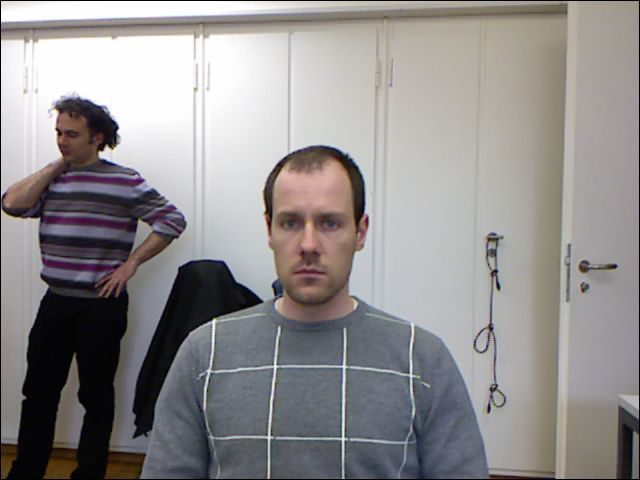

In [48]:
im = Image.open(path/'07/frame_00743_rgb.jpg')
im

In [66]:
get_center(path/'07/frame_00743_rgb.jpg')

tensor([320.3466, 234.3913])

In [70]:
im_arr = array(im)

In [85]:
pred,pred_idx,prob = learn_inf.predict(im)

In [89]:
def mark_center(im, ctr):
  im_array = array(im)
  ctr_x_c = int(ctr[1])
  ctr_y_c = int(ctr[0])
  im_array[ctr_x_c - 4: ctr_x_c + 4, ctr_y_c -4 : ctr_y_c +4] = [255,0,0]
  return Image.fromarray(im_array)


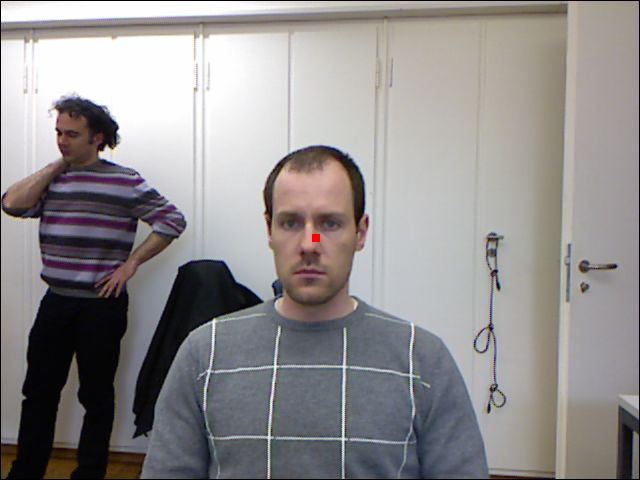

In [93]:
im_marked = mark_center(im, pred[0]*2)
im_marked